In [14]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf
import cvxpy as cvx
import riskfolio as rf

import statsmodels.api as sm

import scipy.stats as st
from scipy.linalg import expm, logm, sqrtm

import datetime as dt
from arch import arch_model

from statsmodels.graphics.tsaplots import plot_pacf

In [141]:
# 1. Generate some artificial ARMA data (for demonstration)
np.random.seed(42)
nobs = 5000
arparams = np.array([0.7, -0.2, 0.5, -0.1])  # AR coefficients
maparams = np.array([0])        # MA coefficients

# Add a leading 1 for the AR and MA polynomial representation
arparams = np.r_[1, -arparams]
maparams = np.r_[1, maparams]

# Generate the ARMA time series
y = sm.tsa.arma_generate_sample(arparams, maparams, nobs, scale=1)

# Optionally, add dates for a pandas Series
dates = pd.date_range("1990-01-01", freq="H", periods=nobs)
y = pd.Series(y, index=dates)

In [142]:
np.mean(y)

np.float64(0.049598023491621415)

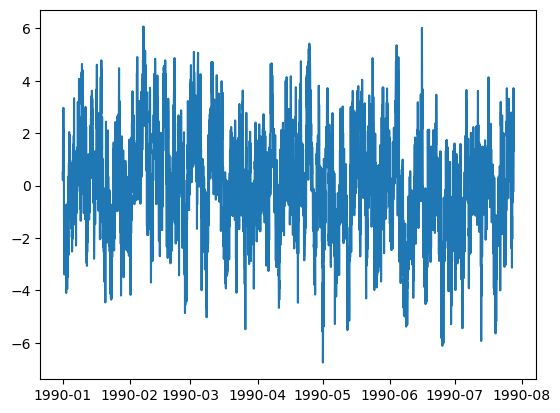

In [143]:
plt.plot(y)

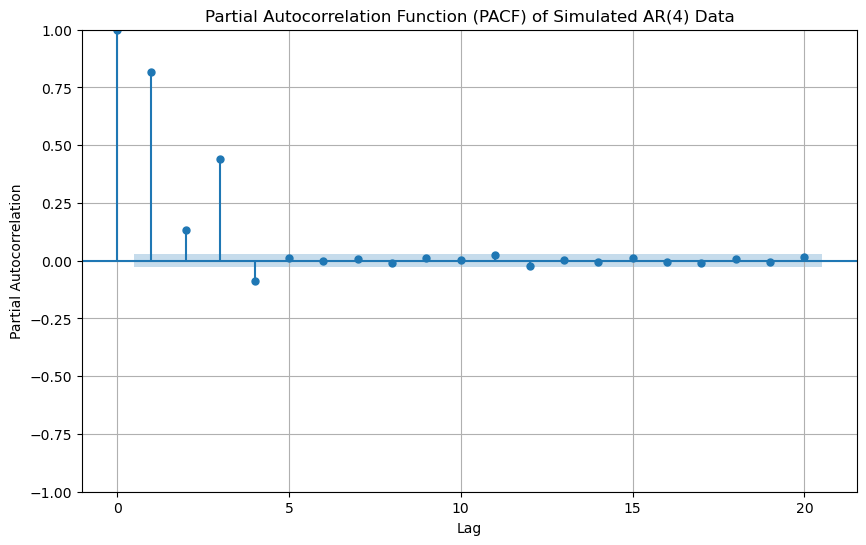

In [144]:
plt.figure(figsize=(10, 6))
plot_pacf(y, lags=20, method='ywm', ax=plt.gca()) # 'ywm' is a common method for PACF calculation
plt.title(f'Partial Autocorrelation Function (PACF) of Simulated AR({len(arparams)-1}) Data')
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

In [145]:
# 2. Fit the ARMA model
# The order parameter is (p, q), where p is the AR order and q is the MA order.
# For an ARMA(2,1) model, the order would be (2, 1).
# We use ARIMA(y, order=(p, 0, q)) for ARMA models in statsmodels.
# 'trend="n"' indicates no constant term in the model.
arma_mod = sm.tsa.ARIMA(y, order=(len(arparams)-1, 0, 0), trend="n")
arma_res = arma_mod.fit()

# 3. Print the model summary
print(arma_res.summary())

# 4. Make predictions (optional)
# Predict the next 10 steps
forecast = arma_res.predict(start=len(y), end=len(y) + 9)
print("\nForecasted values:")
print(forecast)

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 5000
Model:                 ARIMA(4, 0, 0)   Log Likelihood               -7076.625
Date:                Sat, 01 Nov 2025   AIC                          14163.251
Time:                        12:44:30   BIC                          14195.837
Sample:                    01-01-1990   HQIC                         14174.672
                         - 07-28-1990                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6855      0.014     48.220      0.000       0.658       0.713
ar.L2         -0.1915      0.015    -12.488      0.000      -0.222      -0.161
ar.L3          0.4966      0.016     31.309      0.0